# Trying out training with a very simple model 

In [2]:
# import pytorch
import torch

import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.transforms import ToTensor, Lambda
from torch.optim.lr_scheduler import StepLR

import matplotlib.pyplot as plt
import numpy as np

# custom code
import source.preprocessing as cheepre
import mypytorch.mymodels as mm
import mypytorch.dataset_classes as md
import mypytorch.mytrainer as mt


In [42]:
# reload if necessary
import importlib;
importlib.reload(cheepre)
importlib.reload(mm)
importlib.reload(md)
importlib.reload(mt)

<module 'mypytorch.mytrainer' from '/Users/m.wehrens/Documents/git_repos/_UVA/2025_Cheeky-cells/mypytorch/mytrainer.py'>

In [43]:
%%capture
ANNOT_DIR = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_humanannotated/'
IMG_DIR   = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_grey/'
mydataset = md.CustomImageDataset(annot_dir=ANNOT_DIR, 
                               img_dir=IMG_DIR, 
                               transform=ToTensor(), 
                               target_transform=Lambda(lambda y: torch.zeros(6, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)),
                               preload_imgs=True)

Dataset size:  494732


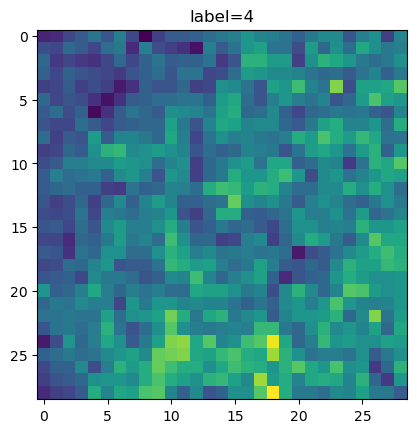

In [44]:
# show one of the images of "mydataset" above
image, label = mydataset[0]
plt.imshow(image.to("cpu")[0])
plt.title('label='+str(np.where(label.to("cpu"))[0][0]))
# also show size of "mydataset"
print('Dataset size: ', len(mydataset))

In [ ]:
# divide mydataset into 20% test set and 80% training set

# Define the sizes of the splits
total_size = len(mydataset)
train_size = int(0.8 * total_size)  # 80% for training
val_size = total_size - train_size   # 20% for validation

# from torch.utils.data import random_split
# Create the splits (in case random sampling is needed)
# train_dataset, val_dataset = random_split(
#     mydataset, 
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(42)  # For reproducibility
# )

# Split the dataset manually, simply taking the first train_size samples
train_dataset = torch.utils.data.Subset(mydataset, range(train_size))
val_dataset = torch.utils.data.Subset(mydataset, range(train_size, total_size))

In [41]:
len(train_dataset)
len(val_dataset)

98947

In [6]:
# Device a weighing scheme, that can be used for evenly distributed sampling
# get label distributions
# horribly slow:
#labels_trainset = [train_dataset[i][1] for i in range(len(train_dataset))] 
#labels_valset   = [val_dataset[i][1] for i in range(len(val_dataset))]
# faster:
original_labels = mydataset.labels
labels_trainset    = original_labels[train_dataset.indices]
labels_valset      = original_labels[val_dataset.indices]

# weights for training set
train_bincounts = np.bincount(labels_trainset)
class_weights_train = 1.0 / train_bincounts
class_weights_train[train_bincounts==0] = 0 # counters div 0
weights_train = class_weights_train[labels_trainset]  # Assign a weight to each sample
# also for val_set
val_bincounts = np.bincount(labels_valset)
class_weights_val = 1.0 / val_bincounts
class_weights_val[val_bincounts==0] = 0
weights_val = class_weights_val[labels_valset]  # Assign a weight to each sample
# set samplers
sampler_train = WeightedRandomSampler(weights_train, num_samples=len(train_dataset), replacement=True)
sampler_val   = WeightedRandomSampler(weights_val, num_samples=len(val_dataset), replacement=True)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, 
                        sampler=sampler_train) # untested

generator = torch.Generator().manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=64, # shuffle=False, 
                        shuffle=False, generator=generator, # untested
                        sampler=sampler_val)

/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_32002/363099376.py:13: RuntimeWarning: divide by zero encountered in divide
  class_weights_train = 1.0 / train_bincounts
/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_32002/363099376.py:18: RuntimeWarning: divide by zero encountered in divide
  class_weights_val = 1.0 / val_bincounts


In [7]:
print(class_weights_val)
print(class_weights_train)

[0.00000000e+00 3.04534519e-05 3.18603243e-05 1.39082058e-04
 4.09115084e-05 3.23624595e-04]
[0.00000000e+00 7.58058158e-06 8.01455443e-06 3.47741419e-05
 1.02091862e-05 8.07232806e-05]


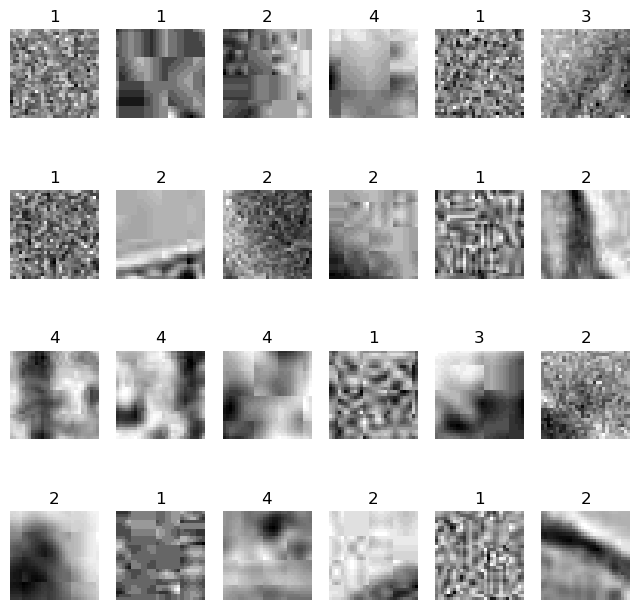

shape img torch.Size([1, 29, 29])


In [37]:
# Show images from the train_dsatset with labels
# train_dataset, val_dataset 

figure = plt.figure(figsize=(8, 8))
cols, rows = 6, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    img, label = img.to("cpu"), label.to("cpu")
    # convert label to default python int
    label_det = str(label.argmax().detach().cpu().numpy())
    figure.add_subplot(rows, cols, i)
    plt.title(   label_det   )
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

print('shape img', img.shape)
# ({int(label.detach().cpu().numpy())})


# Now define the model (CNN)

In [9]:
# get training device
device = "mps" if torch.backends.mps.is_available() else "cpu" # code is different from tutorial (fixed with co-pilot)
print(f"Using {device} device")

Using mps device


In [10]:
# initalize model and move to the correct device
modelCNN = mm.CNN((1, 29, 29),6).to(device)
print(modelCNN)

CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=1600, out_features=6, bias=True)
)


In [11]:
# Load the model if desired
LOAD_MODEL = True
MODEL_PATH = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_CNN_90pct_2025-04-10_18-16.pth'

# Load the model
if LOAD_MODEL:
    modelCNN.load_state_dict(torch.load(MODEL_PATH))
    print(f"Model loaded from {MODEL_PATH}")

Model loaded from /Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_CNN_90pct_2025-04-10_18-16.pth


/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_32002/3303302242.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelCNN.load_state_dict(torch.load(MODEL_PAT

In [12]:
# We can now already call the model

X = torch.rand(1, 1, 29, 29, device=device) # random image as test input
logits = modelCNN(X) # "logits" refers to raw, unnormalized outputs of the final layer of a neural network
print('logits:', logits)
print('shape',logits.shape)
#pred_probab = nn.Softmax(dim=1)(logits) # converts output layer to probabilities
#print(f'Probabilities: {pred_probab}')
#y_pred = pred_probab.argmax(1) # finds the most likely label
#print(f"Predicted class: {y_pred}")

logits: tensor([[-166.9326,  -41.9205,  -19.3332,  -73.2431,   39.9633,  -39.4131]],
       device='mps:0', grad_fn=<LinearBackward0>)
shape torch.Size([1, 6])


In [23]:
# Same but for img loaded above
Xtestimg = img.to("mps").unsqueeze(0)
logits = modelCNN(Xtestimg) # "logits" refers to raw, unnormalized outputs of the final layer of a neural network
print('logits:', logits)
print('shape',logits.shape)
print('ground truth=',label)

Xtestimg.shape
# img.to(device).device

logits: tensor([[-49.9603,  11.2937,   6.1070, -10.0513,   8.8660, -66.2416]],
       device='mps:0', grad_fn=<LinearBackward0>)
shape torch.Size([1, 6])
ground truth= tensor([0., 1., 0., 0., 0., 0.])


torch.Size([1, 1, 29, 29])

# Now train the model

In [24]:
# Hyperparameters

# Hyperparameters are not parameters that define the model, but parameters that 
# relate to finding the solution;
    # - numbers of epochs: number of times to iterate over the whole dataset
    # - batch size: (PB) typically the loss of multiple instances is calculated in 
    #   paralellel; the loss is then determined as L(L1, L2, L3, L_batchsize), typically just
    #   sum. The backward propagation needs to be called from a single scalar
    #   tensor; So you simply define L = L1 + L2 + L3 + L_batchsize, the tensor 
    #   concept allows then backpropagation on L, implicitly taking all L_i into
    #   account.
    # - learning rate: how much to update models parameters at each batch/epoc;
        # I'm guessing this is some factor sets the size of W updates.

learning_rate = 1e-3 # 1e-3

# We need to set loss function, and optimizer
#loss_fn = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    # optimizer will actually implement some form of gradient descent
 
# From CNN   
loss_fn = torch.nn.CrossEntropyLoss()  # loss function
optimizer = torch.optim.Adam(modelCNN.parameters(), learning_rate)

    

In [17]:
# The training loop is custom coded

TOTAL_SAMPLES     = int(100_000)
TOTAL_TESTSAMPLES = int(10_000)
BATCH_SIZE        = 64
NUM_TESTBATCHES   = int(np.ceil(TOTAL_TESTSAMPLES/64))



In [48]:
# Now actually execute the training


# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=15, gamma=0.1) # step_size=10

epochs = 30 # 30
list_loss_tracker = []
list_correct = []
for t in range(epochs):
    
    print(f"Epoch {t+1}, LR: {scheduler.get_last_lr()}")
    
    # train and test
    loss_tracker = mt.train_loop(train_loader, modelCNN, loss_fn, optimizer, TOTAL_SAMPLES=TOTAL_SAMPLES, BATCH_SIZE=BATCH_SIZE)
    current_correct  = mt.test_loop(val_loader, modelCNN, loss_fn, NUM_TESTBATCHES=NUM_TESTBATCHES)
    
    # update scheduler
    scheduler.step()
    
    # track loss & test correctness
    list_loss_tracker.append(loss_tracker)    
    list_correct.append(current_correct)
    
print("Done!")

# estimated training time:
# 25664 samples = 1:40 = 100 s
# ±40x as long --> 4000 seconds --> ±1hr 6min

Epoch 1, LR: [0.001]
loss: 1.796417  [   64/100000]
loss: 1.448156  [ 6464/100000]
loss: 1.211004  [12864/100000]
loss: 1.155265  [19264/100000]
loss: 1.095665  [25664/100000]
loss: 1.289811  [32064/100000]
loss: 1.099372  [38464/100000]
loss: 1.126146  [44864/100000]
loss: 0.989969  [51264/100000]
loss: 0.829044  [57664/100000]
loss: 0.936414  [64064/100000]
loss: 0.949379  [70464/100000]
loss: 0.910464  [76864/100000]
loss: 0.902966  [83264/100000]
loss: 0.840620  [89664/100000]
loss: 0.834573  [96064/100000]
Epoch done
Predicting for test set.
Batch 0
Batch 25
Batch 50
Batch 75
Batch 100
Batch 125
Batch 150
Test Error: 
 Accuracy: 68.8%, Avg loss: 0.835246 

Epoch 2, LR: [0.001]
loss: 0.699516  [   64/100000]
loss: 0.799631  [ 6464/100000]
loss: 1.012431  [12864/100000]
loss: 0.783194  [19264/100000]
loss: 0.779986  [25664/100000]
loss: 0.772546  [32064/100000]
loss: 0.657307  [38464/100000]
loss: 0.716959  [44864/100000]
loss: 0.782596  [51264/100000]
loss: 0.929225  [57664/100000]

In [1]:
# Now save the model and its weights
# generate current date
import datetime
current_date = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
PATH = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_CNN_'+current_date+'.pth'
torch.save(modelCNN.state_dict(), PATH)

NameError: name 'torch' is not defined

In [54]:
# import datetime
# datetime.datetime.now()
# .strftime("%Y-%m-%d_%H:%M")

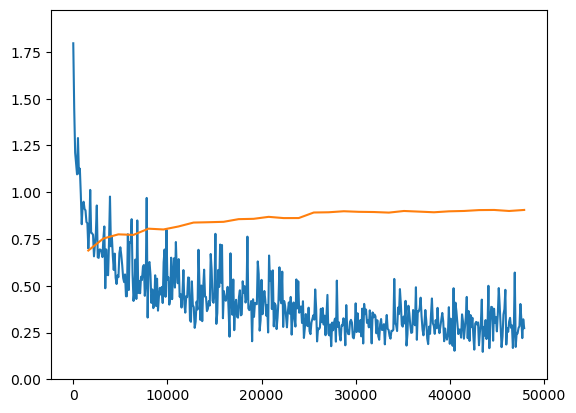

In [55]:
# Plot list_loss_tracker

import matplotlib.pyplot as plt
import numpy as np

datay = np.array(list_loss_tracker).flatten()
datax = np.array(range(len(datay)))*100
plt.plot(datax, datay)
plt.ylim([0, np.max(datay)*1.1])
datax[-1]

# and also plot the list_correct
data_correctx = np.linspace(datax[-1]/epochs, datax[-1], epochs)
data_correcty = np.array(list_correct)
plt.plot(data_correctx, data_correcty)


# Debugging

In [19]:
# load the model if desired (debugging purposes)

PATH='/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_CNN_90pct_2025-04-10_18-16.pth'
modelCNN = mm.CNN((1, 29, 29),6).to("mps")

modelCNN.load_state_dict(torch.load(PATH, weights_only=True))
modelCNN.eval()

CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=1600, out_features=6, bias=True)
)

In [20]:
# Run an additional test loop for debugging..

loss_fn = torch.nn.CrossEntropyLoss()  # loss function
mt.test_loop(val_loader, modelCNN, loss_fn, NUM_TESTBATCHES=NUM_TESTBATCHES)

Predicting for test set.
Batch 0
Batch 25
Batch 50
Batch 75
Batch 100
Batch 125
Batch 150
Test Error: 
 Accuracy: 90.9%, Avg loss: 0.271518 



0.9087380573248408

In [36]:
# get one sample from the dataloader val_loader
(X, y) = next(iter(val_loader))
X.dtype
X.max()


tensor(0.8549, device='mps:0')

In [33]:
# I can also simply load the 50 first test set images
mydataset[:50]

TypeError: only integer scalar arrays can be converted to a scalar index